<a href="https://colab.research.google.com/github/Camacho-umu/CamachoMu-ozRuiz/blob/main/SEMIGRADIENTSARSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SARSA Semi-Gradiente aplicado a CartPole-v1

## Planteamiento del Problema

En este notebook se implementa y evalúa el algoritmo **SARSA Semi-Gradiente** en el entorno **CartPole-v1 de Gymnasium**.

### ¿Qué es CartPole?
Un poste (péndulo invertido) está unido a un carro sobre una pista sin fricción. El agente debe mantener el poste en equilibrio aplicando fuerzas a izquierda o derecha.

- **Espacio de estados**: Continuo (4 dimensiones: posición del carro, velocidad del carro, ángulo del poste, velocidad angular del poste).
- **Espacio de acciones**: Discreto (2 acciones: empujar a la izquierda o a la derecha).
- **Recompensa**: +1 por cada paso en el que el poste permanece en equilibrio.
- **Terminación**: El episodio termina si el poste se inclina más de 12° o el carro sale de los límites, o tras 500 pasos (truncamiento).

### ¿Por qué SARSA Semi-Gradiente?
**SARSA Semi-Gradiente** extiende SARSA usando un modelo parametrizado para estimar $Q(s,a)$. La actualización de los parámetros se hace con el gradiente de la función aproximada, pero tratando el valor objetivo como fijo (de ahí lo de "semi-gradiente"). Esto permite aplicar actualizaciones incrementales basadas en el error temporal (TD error) sin propagar el gradiente a través del target, lo que facilita el aprendizaje en espacios de estados continuos como CartPole.

### Función de Recompensa
- **+1** por cada paso en el que el poste se mantiene en equilibrio.
- El episodio se **trunca** a los 500 pasos (éxito máximo).
- No hay penalizaciones explícitas, pero el episodio acaba antes si el poste cae o el carro sale de los límites.

In [ ]:
#@title Instalación de librerías necesarias
%pip install gymnasium moviepy torch
%pip install gymnasium[classic-control]
%pip install tqdm matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\Rodrigo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\Rodrigo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
#@title Importación de librerías

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import io
import base64
from IPython import display
from IPython.display import HTML
from tqdm import tqdm

## Configuración de la semilla
Se fija una **semilla** para que los resultados del entrenamiento sean reproducibles.

In [ ]:
#@title Semilla
import os
import numpy as np
import gymnasium as gym

# Configuración de la semilla para reproducibilidad
seed = 2026

np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

## Declaración del entorno CartPole-v1

Creamos el entorno **CartPole-v1** de Gymnasium. A diferencia de FrozenLake (que tiene un espacio de estados discreto), CartPole posee un **espacio de estados continuo** de 4 dimensiones:

| Variable | Descripción | Rango |
|----------|-------------|-------|
| Posición del carro | Posición horizontal del carro | [-4.8, 4.8] |
| Velocidad del carro | Velocidad lineal del carro | [-∞, ∞] |
| Ángulo del poste | Ángulo respecto a la vertical | [-0.418 rad, 0.418 rad] |
| Velocidad angular | Velocidad angular del poste | [-∞, ∞] |

Las acciones son discretas: **0** (empujar izquierda) o **1** (empujar derecha).

In [ ]:
#@title Importamos el entorno CartPole-v1
name = 'CartPole-v1'

# Creamos el entorno CartPole-v1
env = gym.make(name, render_mode="rgb_array")

## Funciones auxiliares para representar las gráficas

Funciones de visualización para analizar el rendimiento del agente:

- **`plot()`**: Muestra la evolución de las recompensas por episodio con línea de tendencia.
- **`plot_episode_lengths()`**: Muestra la evolución de la longitud de los episodios con línea de tendencia.

In [ ]:
#@title Funciones de visualización de desempeño del agente durante el entrenamiento
import numpy as np
import matplotlib.pyplot as plt

def plot_episode_lengths(episode_lengths):
    """Representa la evolución de la longitud de los episodios con línea de tendencia."""
    episode_lengths = np.array(episode_lengths)

    x = np.arange(len(episode_lengths))
    coefficients = np.polyfit(x, episode_lengths, 1)
    trend_line = np.polyval(coefficients, x)

    plt.figure(figsize=(8, 4))
    plt.plot(episode_lengths, label="Longitud del episodio", alpha=0.5)
    plt.plot(x, trend_line, label="Línea de tendencia", color='red')
    plt.xlabel("Episodio")
    plt.ylabel("Longitud")
    plt.title("Evolución de la longitud de los episodios")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot(list_stats):
    """Muestra la evolución de las recompensas con línea de tendencia."""
    indices = list(range(len(list_stats)))

    list_stats = np.array(list_stats)

    x = np.arange(len(list_stats))
    coefficients = np.polyfit(x, list_stats, 1)
    trend_line = np.polyval(coefficients, x)

    plt.figure(figsize=(8, 4))
    plt.plot(indices, list_stats, label='Recompensa por episodio', alpha=0.5)
    plt.plot(x, trend_line, label="Línea de tendencia", color='red')
    plt.title('Evolución de las recompensas por episodio')
    plt.xlabel('Episodio')
    plt.ylabel('Recompensa')
    plt.grid(True)
    plt.legend()
    plt.show()

## Funciones para crear y reproducir los vídeos

- **`get_latest_episode_video_file`**: Busca en un directorio el vídeo `.mp4` del episodio más reciente.
- **`embed_video`**: Incrusta y reproduce un vídeo en el notebook codificándolo en base64.
- **`record_policy_with_fn_SarsaDQL`**: Graba un vídeo ejecutando la política greedy aprendida (sin exploración). Recibe la función de política y el agente como parámetros.

In [ ]:
def get_latest_episode_video_file(directory):
    """
    Devuelve el nombre (con ruta) del video .mp4 de episodio
    más reciente en 'directory', siguiendo el patrón
    'rl-video-episode-.mp4'.
    """
    pattern = re.compile(r"rl-video-episode-(\d+)\.mp4")
    latest_file = None
    highest_episode = -1
    for filename in os.listdir(directory):
        match = pattern.match(filename)
        if match:
            episode_number = int(match.group(1))
            if episode_number > highest_episode:
                highest_episode = episode_number
                latest_file = os.path.join(directory, filename)
    return latest_file

def embed_video(video_file):
    """
    Incrusta el video .mp4 en el notebook a partir de su ruta.
    """
    video_data = io.open(video_file, 'r+b').read()
    encoded_data = base64.b64encode(video_data).decode()
    display.display(HTML(data=f'''
        <video width="640" height="480" controls>
            <source src="data:video/mp4;base64,{encoded_data}" type="video/mp4">
            Your browser does not support the video tag.
        </video>'''))

def record_policy_with_fn_SarsaDQL(policy_fn, agent, env, video_dir="videos"):
    """Graba un video ejecutando una política greedy sin exploración."""
    os.makedirs(video_dir, exist_ok=True)

    env = gym.wrappers.RecordVideo(env, video_folder=video_dir, episode_trigger=lambda ep: ep == 0)

    state, _ = env.reset(seed=seed)
    done = False

    while not done:
        action = policy_fn(state, agent)
        state, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    env.close()

    return video_dir

## Definición del agente SARSA Semi-Gradiente

A diferencia de FrozenLake (estado discreto con one-hot encoding), en **CartPole el estado es continuo** (4 variables reales). La clase `SARSASemiGradient` se adapta para trabajar directamente con vectores de características continuos.

### Cambios respecto a la versión de FrozenLake:
1. **Normalización del estado**: Las 4 variables tienen escalas muy distintas (posición ±4.8, ángulo ±0.418, velocidades potencialmente grandes). Se normaliza cada dimensión por su rango típico para que todas las características contribuyan de forma equilibrada.
2. **`featurize_state_action()`**: Genera un vector donde el estado normalizado (4 dims) se coloca en la posición de la acción seleccionada, con ceros en el resto. Tamaño total: `state_dim × n_actions`.
3. **Pesos `w`**: Se inicializan con la dimensión correcta (`state_dim × n_actions = 8`).
4. **`q_value()`**: Calcula $Q(s,a) = \mathbf{w}^T \cdot \mathbf{x}(s,a)$ como producto escalar.
5. **Decaimiento de epsilon por episodio**: Si se decayera por paso, la exploración cesaría demasiado rápido en episodios largos (hasta 500 pasos en CartPole).

### Fórmula de actualización Semi-Gradiente:
$$\mathbf{w} \leftarrow \mathbf{w} + \alpha \cdot \delta \cdot \nabla_w \hat{Q}(s, a, \mathbf{w})$$

Donde $\delta = R + \gamma \hat{Q}(s', a', \mathbf{w}) - \hat{Q}(s, a, \mathbf{w})$ es el **error temporal (TD error)** y $\nabla_w \hat{Q}(s, a, \mathbf{w}) = \mathbf{x}(s, a)$ (en el caso lineal, el gradiente es el propio vector de características).

Se llama "semi-gradiente" porque **no se propaga el gradiente a través del target** $R + \gamma \hat{Q}(s', a', \mathbf{w})$, que se trata como un valor fijo.

In [ ]:
class SARSASemiGradient:
    def __init__(self, env, alpha=0.01, gamma=0.99, epsilon=1.0, epsilon_decay=0.9995, min_epsilon=0.01):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

        # Dimensiones del espacio de estados y acciones
        self.state_dim = env.observation_space.shape[0]  # 4 para CartPole
        self.n_actions = env.action_space.n               # 2 para CartPole

        # Rangos típicos para normalización de estado en CartPole
        # [posición, velocidad, ángulo, velocidad angular]
        self.state_scales = np.array([4.8, 3.0, 0.418, 3.0])

        # Inicializar pesos w con valores pequeños
        # Vector de pesos: state_dim * n_actions (cada acción tiene su propio conjunto de pesos)
        self.w = np.random.rand(self.state_dim * self.n_actions) * 0.01

    def normalize_state(self, state):
        """
        Normaliza el estado dividiendo por los rangos típicos y recortando valores extremos.
        Esto asegura que todas las dimensiones tengan escalas similares,
        lo cual es crucial para que el modelo lineal aprenda correctamente.
        """
        state = np.clip(state, -self.state_scales * 2, self.state_scales * 2)
        return state / self.state_scales

    def featurize_state_action(self, state, action):
        """
        Codificación de estado-acción para espacio continuo.
        Normaliza el estado y lo coloca en la posición
        correspondiente a la acción seleccionada.
        El resto se llena con ceros.
        """
        norm_state = self.normalize_state(state)
        features = np.zeros(self.state_dim * self.n_actions)
        start = action * self.state_dim
        features[start:start + self.state_dim] = norm_state
        return features

    def q_value(self, state, action):
        """Calcula Q(s,a) como w^T * x(s,a)"""
        features = self.featurize_state_action(state, action)
        return np.dot(self.w, features)

    def get_action(self, state):
        """Política epsilon-greedy"""
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.n_actions)  # Exploración
        else:
            return np.argmax([self.q_value(state, a) for a in range(self.n_actions)])  # Explotación

    def update(self, state, action, reward, next_state, next_action, done):
        """Actualización de pesos w con semi-gradiente"""
        features = self.featurize_state_action(state, action)
        target = reward + (0 if done else self.gamma * self.q_value(next_state, next_action))
        error = target - self.q_value(state, action)
        self.w += self.alpha * error * features  # Gradiente ascendente

## Inicialización y Entrenamiento del Agente

Se crea el entorno CartPole-v1 con grabación de vídeo y se inicializa el agente con los siguientes **hiperparámetros**:

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| `NUM_EPISODES` | 5000 | Episodios de entrenamiento |
| `alpha` | 0.01 | Tasa de aprendizaje (más alta que en DQN, adecuada para modelos lineales) |
| `gamma` | 0.99 | Factor de descuento |
| `epsilon` | 1.0 | Prob. inicial de exploración |
| `epsilon_decay` | 0.9995 | Decaimiento de epsilon **por episodio** |
| `min_epsilon` | 0.01 | Valor mínimo de epsilon |

### Bucle de entrenamiento (On-Policy)
SARSA es **on-policy**: evalúa y mejora la misma política que usa para seleccionar acciones. El nombre viene de la secuencia $(S, A, R, S', A')$:
1. Estado actual $S$, se elige acción $A$ con $\varepsilon$-greedy.
2. Se recibe recompensa $R$ y siguiente estado $S'$.
3. Se elige siguiente acción $A'$ con la misma política.
4. Se actualiza $Q(S, A)$ usando el target $R + \gamma Q(S', A')$.

### Nota sobre el decaimiento de epsilon:
El decaimiento se hace **por episodio**, no por paso. En CartPole los episodios pueden durar hasta 500 pasos, así que decaer por paso haría que la exploración se agotara demasiado rápido.

In [ ]:
# Hiperparámetros
NUM_EPISODES = 5000

# Crear entorno con grabación de video cada 500 episodios
env_sarsa_sg = gym.make("CartPole-v1", render_mode="rgb_array")
env_sarsa_sg = gym.wrappers.RecordVideo(env_sarsa_sg, video_folder="videos_sarsa_sg_cartpole",
                                        episode_trigger=lambda ep: ep % 500 == 0)

# Inicializar el agente SARSA Semi-Gradiente
agent = SARSASemiGradient(
    env=env_sarsa_sg,
    alpha=0.01,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.9995,
    min_epsilon=0.01
)

# Variables de entrenamiento
rewards_per_episode_sarsa_sg = []
episodes_sizes_sarsa_sg = []

stats = 0.0
list_stats = [stats]
step_display = NUM_EPISODES // 10

# Rastrear la mejor recompensa
best_reward = -float('inf')
best_episode = 0
best_weights = None

# Bucle de entrenamiento
for episode in tqdm(range(NUM_EPISODES)):
    obs, info = env_sarsa_sg.reset(seed=seed)
    action = agent.get_action(obs)
    done = False
    episode_reward = 0
    episode_steps = 0

    while not done:
        next_obs, reward, terminated, truncated, info = env_sarsa_sg.step(action)
        done = terminated or truncated
        next_action = agent.get_action(next_obs) if not done else None

        agent.update(obs, action, reward, next_obs, next_action, done)

        obs, action = next_obs, next_action
        episode_reward += reward
        episode_steps += 1

    # Rastrear la mejor ejecución
    if episode_reward > best_reward:
        best_reward = episode_reward
        best_episode = episode
        best_weights = agent.w.copy()

    # Guardar métricas
    stats += episode_reward
    list_stats.append(stats / (episode + 1))
    rewards_per_episode_sarsa_sg.append(episode_reward)
    episodes_sizes_sarsa_sg.append(episode_steps)

    # Reducir epsilon por episodio (no por paso)
    agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)

    # Progreso
    if episode % step_display == 0 and episode != 0:
        print(f"Recompensa promedio: {stats / episode:.2f}, Épsilon: {agent.epsilon:.4f}, Mejor recompensa: {best_reward}")

print(f"\nEntrenamiento de SARSA Semi-Gradiente completado.")
print(f"Mejor episodio: {best_episode} con recompensa: {best_reward}")

C:\Users\Rodrigo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Rodrigo\Downloads\EML\Entornos Complejos\Aproximados\videos_sarsa_sg_cartpole folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
 10%|█         | 517/5000 [00:01<00:10, 447.29it/s]

Éxito promedio: 30.16, Épsilon: 0.7784, Mejor recompensa: 149.0


 20%|██        | 1013/5000 [00:02<00:13, 291.44it/s]

Éxito promedio: 37.85, Épsilon: 0.6062, Mejor recompensa: 179.0


 30%|██▉       | 1481/5000 [00:04<00:12, 284.42it/s]

...

Éxito promedio: 43.77, Épsilon: 0.1352, Mejor recompensa: 298.0


 90%|█████████ | 4512/5000 [00:11<00:01, 400.85it/s]

Éxito promedio: 42.34, Épsilon: 0.1053, Mejor recompensa: 298.0


100%|██████████| 5000/5000 [00:12<00:00, 402.71it/s]


Entrenamiento de SARSA Semi-Gradiente completado.
Mejor episodio: 1222 con recompensa: 298.0


## Análisis de Resultados: Recompensas por Episodio

La gráfica muestra cómo evolucionan las **recompensas** del agente SARSA Semi-Gradiente en CartPole-v1 a lo largo de 5000 episodios.

### Observaciones:
- **Fase de aprendizaje (episodios 0-1500)**: El agente mejora progresivamente, con picos de hasta **298 pasos** (mejor episodio: 1222). El modelo lineal consigue representar parcialmente la dinámica del péndulo invertido.
- **Fase de declive (episodios 1500-5000)**: La recompensa promedio baja de forma gradual. La **línea de tendencia roja es decreciente**, mostrando pérdida de rendimiento a largo plazo.
- **Recompensa máxima de 298** (de un máximo de 500): el agente aprendió a mantener el poste en equilibrio un tiempo considerable, pero no llega a dominar el entorno.

### ¿Por qué estos resultados?

**El agente aprende al principio** porque, para ángulos pequeños del poste (cerca del equilibrio), la dinámica del péndulo es aproximadamente lineal ($\sin(\theta) \approx \theta$). Con $\varepsilon$ todavía alto (~0.78-0.47), el agente explora lo suficiente para encontrar combinaciones de estado-acción útiles, y el modelo lineal $Q(s,a) = \mathbf{w}^T \mathbf{x}(s,a)$ consigue una aproximación razonable de la función de valor.

**El rendimiento decae** por varias razones que se refuerzan entre sí:
- Los métodos TD con aproximación de funciones **no garantizan convergencia** cuando hay bootstrapping (Sutton & Barto, 2018, Cap. 11). El target $R + \gamma Q(s', a')$ depende de los propios pesos $\mathbf{w}$, así que cada actualización modifica el objetivo al que se intenta llegar.
- La función $Q$ real de CartPole es no lineal (depende de $\sin(\theta)$, $\cos(\theta)$, productos cruzados). El modelo lineal introduce un error de aproximación que, al acumularse con el bootstrapping, acaba arrastrando los pesos hacia configuraciones peores.
- A partir del episodio ~1500, $\varepsilon$ cae por debajo de 0.47, reduciendo la exploración. El agente deja de visitar estados que podrían compensar el sesgo acumulado.

**No alcanza 500 pasos** porque el modelo con 8 pesos ($4 \times 2$) no tiene capacidad para representar las interacciones no lineales entre variables (por ejemplo, la relación entre velocidad angular y ángulo). Para eso harían falta características adicionales (polinomios, RBFs) o directamente un modelo no lineal como una red neuronal.

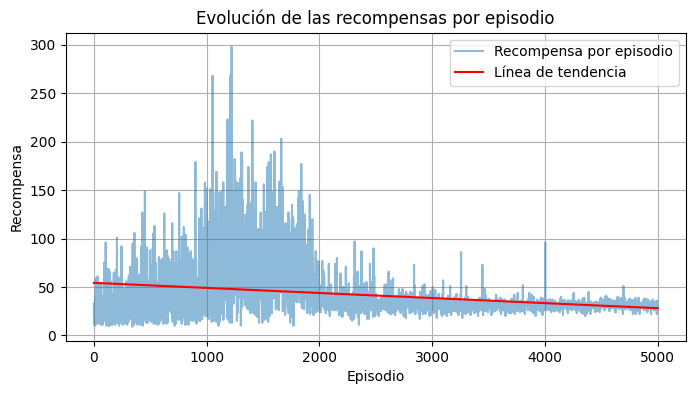

In [ ]:
plot(rewards_per_episode_sarsa_sg)

## Análisis de Resultados: Longitud de los Episodios

La gráfica de longitud refleja el mismo patrón que la de recompensas (en CartPole la longitud coincide con la recompensa, ya que cada paso suma +1):

- **Pico de rendimiento** en torno a los episodios 1000-1500, donde el agente llega a mantener el poste durante **298 pasos**.
- **Declive posterior**: La longitud baja progresivamente hasta estabilizarse en torno a **20-30 pasos** en los episodios finales.

### ¿Por qué estos resultados?

La estabilización en ~20-30 pasos no es casual: es aproximadamente lo que tarda el poste en caer desde el equilibrio sin correcciones útiles (similar a una política casi aleatoria). Los pesos finales del modelo han perdido la información útil aprendida antes, ya que las actualizaciones semi-gradiente han seguido desplazándolos en direcciones subóptimas.

La tendencia descendente es una manifestación práctica de la **deadly triad** (Sutton & Barto, 2018): la combinación de aproximación de funciones, bootstrapping y política cambiante puede llevar a inestabilidad y divergencia. SARSA es on-policy, pero el decaimiento de $\varepsilon$ hace que la política varíe continuamente, lo que introduce un comportamiento semi off-policy que contribuye a la inestabilidad.

Frente a DQN, que usa Experience Replay y Target Network para estabilizar, SARSA Semi-Gradiente aplica cada actualización directamente sobre los pesos sin ningún buffer ni red objetivo. Cada experiencia modifica los pesos de forma inmediata, lo que amplifica la varianza y contribuye a la divergencia.

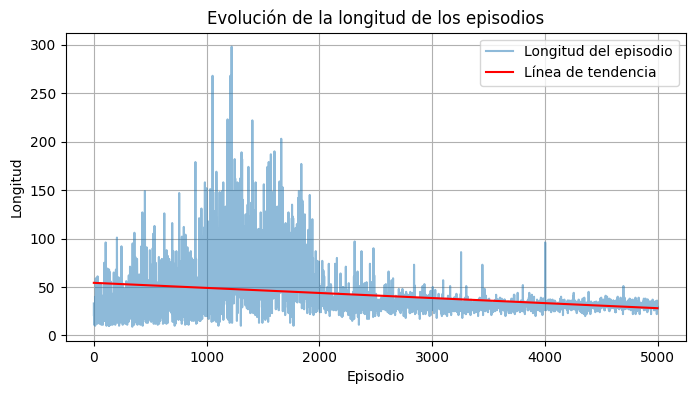

In [ ]:
plot_episode_lengths(episodes_sizes_sarsa_sg)

## Evaluación de la Política Óptima

Se cargan los **mejores pesos** encontrados durante el entrenamiento y se define la función de política greedy, que selecciona la acción con mayor $Q(s,a)$ sin exploración ($\varepsilon = 0$).

Al usar los mejores pesos (en lugar de los finales, que están degradados) nos aseguramos de evaluar la mejor política que el agente consiguió a lo largo del entrenamiento.

In [ ]:
# Cargar los mejores pesos encontrados durante el entrenamiento
agent.w = best_weights.copy()
print(f"Cargados los pesos del mejor episodio ({best_episode}) con recompensa: {best_reward}")

def greedy_policy_sarsa_sg(state, agent):
    """Selecciona la acción óptima para SARSA Semi-Gradiente usando la función aproximadora."""
    return np.argmax([agent.q_value(state, a) for a in range(agent.n_actions)])

Cargados los pesos del mejor episodio (1222) con recompensa: 298.0


## Grabación y Visualización del Vídeo

Se graba un vídeo del agente ejecutando la **política greedy** con los mejores pesos obtenidos durante el entrenamiento.

En el vídeo se puede ver al agente compensando con movimientos del carro a izquierda y derecha para mantener el poste en equilibrio. Con los mejores pesos, el agente sostiene el poste un tiempo considerable, aunque se notan las limitaciones del modelo lineal al no poder mantenerlo indefinidamente.

In [ ]:
# Crear un nuevo entorno limpio para la grabación del vídeo
env_video = gym.make("CartPole-v1", render_mode="rgb_array")

# Grabar el video con la mejor política aprendida
video_dir = record_policy_with_fn_SarsaDQL(greedy_policy_sarsa_sg, agent, env_video, video_dir="videos_sarsa_sg_cartpole_best")

# Obtener el último video grabado
latest_video_file = get_latest_episode_video_file(video_dir)

# Mostrar información del video grabado
print("Video grabado:", latest_video_file)

# Mostrar el video en el notebook
embed_video(latest_video_file)

C:\Users\Rodrigo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Rodrigo\Downloads\EML\Entornos Complejos\Aproximados\videos_sarsa_sg_cartpole_best folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Video grabado: videos_sarsa_sg_cartpole_best\rl-video-episode-0.mp4


## Conclusiones

### SARSA Semi-Gradiente en CartPole-v1

El agente logró una recompensa máxima de **298 pasos** (episodio 1222), lo que demuestra que el modelo lineal captura parcialmente la dinámica del péndulo invertido. Para desviaciones pequeñas del equilibrio, la dinámica es aproximadamente lineal ($\sin(\theta) \approx \theta$) y el modelo aprovecha esa simplificación en las fases tempranas del entrenamiento.

Sin embargo, la recompensa promedio muestra una **tendencia descendente** tras el episodio ~1500. Esto es consecuencia de la *deadly triad* (Sutton & Barto, 2018): la combinación de aproximación de funciones, bootstrapping y política cambiante genera actualizaciones que no convergen a un punto fijo. Sin mecanismos de estabilización (Experience Replay, Target Network), los pesos acaban derivando hacia configuraciones peores.

La **normalización** de las características fue un paso necesario. Sin ella, los gradientes estarían dominados por las variables de rango grande (posición ±4.8) e impedirían que variables de rango pequeño pero importantes (ángulo ±0.418) contribuyeran al aprendizaje, dado que $\nabla_w Q = \mathbf{x}(s,a)$.

Con solo **8 parámetros** ($4 \times 2$), el modelo no puede representar la función Q real, que involucra términos como $\sin(\theta)$, $\cos(\theta)$ y productos cruzados. Para mejorar harían falta funciones base más ricas (polinomios, RBFs) o un aproximador no lineal.

### Comparación con DQN

| Aspecto | SARSA Semi-Gradiente | DQN |
|---|---|---|
| Modelo | Lineal (8 params) | Red neuronal (~4290 params) |
| Política | On-policy | Off-policy |
| Estabilización | Ninguna | Experience Replay + Target Net |
| Mejor recompensa | 298 / 500 (59.6%) | **500 / 500 (100%)** |
| Tendencia | Decreciente | **Creciente** |
| Deadly triad | Sin mitigación | Mitigada |

La diferencia de rendimiento se explica por la capacidad de la red neuronal para representar no linealidades, junto con los mecanismos de estabilización que previenen la divergencia. A pesar de sus limitaciones, SARSA Semi-Gradiente resulta esencial para entender los fundamentos de la aproximación de funciones en RL —la featurización del estado, la actualización semi-gradiente y los riesgos de la deadly triad— y por qué las técnicas de DQN fueron necesarias.